# **1. 손글씨 도형 분류하기**
- 손으로 그린 원, 삼각형, X 이미지를 CNN으로 분류
- 데이터 구성: 학습 데이터 240장, 테스트 60장, 3개의 클래스가 균등하게 구성

In [1]:
import os
import random
import torch
import torch.nn as nn
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [2]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
extract_dir = Path("./data")
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# 압축 풀기
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall(extract_dir)

In [5]:
shape_root = extract_dir / 'shape'
train_dir = shape_root / 'train'
test_dir = shape_root / 'test'
print('Train Directory: ', train_dir)
print('Test Directory: ',test_dir)

Train Directory:  data\shape\train
Test Directory:  data\shape\test


### ImageFolder
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함

In [6]:
# data/shape/train -> cir(0), tri(1), x(2)
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)
print('Class: ', raw_train.classes)
print('Class Num: ', raw_train.class_to_idx)
print('Train Data Image Num: ', len(raw_train))
print('Test Data Image Num: ', len(raw_test))

Class:  ['cir', 'tri', 'x']
Class Num:  {'cir': 0, 'tri': 1, 'x': 2}
Train Data Image Num:  240
Test Data Image Num:  60


# **2. 전처리와 데이터 증강**
- Info: 배경을 검은색으로 바꾸는게 효과적이고 성능 높아짐 (흰: 255, 검: 0)
- 모든 이미지를 28*28 1채널 흑백으로 통일함
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖게 함
- 픽셀 값을 텐서로 바꾼 뒤, 평균 0.5, 표준편차 0.5로 정규화
- 학습 데이터에만 작은 회전/이동/크기 변화를 적용. 일반화 성능을 높임

In [7]:
# Train용 transform
# Compose: 리스트 안의 변화들을 '순서대로' 변화시킴
train_transform = transforms.Compose([
    transforms.Resize((28, 28)), 
    transforms.Grayscale(num_output_channels=1),  # Grayscale로 변환
    transforms.RandomInvert(p=1.0), # 모든 이미지를 반전
    transforms.RandomAffine(
        degrees=12,  
        translate=(0.08, 0.08),  # x, y 축으로 랜덤하게 이동
        scale=(0.90, 1.10), # 크기 조정
    ),
    transforms.ToTensor(), # 한 픽셀당 0~255 색상 값을 0~1 사이의 값으로 변환

    # transforms.ToTensor()를 거쳐 0~1사이로 바뀐 픽셀 값에 (값-0.5) / 0.5 공식을 적용해 중앙값을 0, 범위를 -1~1로 조절 -> 인공지능 모델이 더 빠르고 안정적으로 학습할 수 있게 함
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# 테스트용 transform
eval_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# 3. **학습/검증/테스트 데이터 분리**
- 학습 데이터: 가중치를 실제로 업데이트 함
- 검증 데이터: 학습 중 모델 선택과 과적합 확인에 사용
- 테스트 데이터: 모든 학습과 모델 선택이 끝난 뒤, 최종 성능을 확인

In [8]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes

3

In [9]:
train_indices = []
val_indices = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0]
    rng.shuffle(indices)
    split = int(len(indices) * 0.8)
    train_indices.extend(indices[:split].tolist())  # 첫 80프로 train_indices
    val_indices.extend(indices[split:].tolist())  # 나머지 20프로 val_indices

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# 기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 만듦
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print('Train: ', len(train_dataset))
print('Val: ', len(val_dataset))
print('Test: ', len(test_dataset))


Train:  192
Val:  48
Test:  60


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0, # CPU 다 써라
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# **4. 이미지와 텐서 모양 확인**
- CNN 입력 텐서는 [배치, 채널(흑백=1, 컬러=3), 높이, 너비] 순서
- 현재 위 데이터의 한 배치의 shape는 [32, 1, 28, 28]

In [11]:
images, labels = next(iter(train_loader))  # 32개 이미지와 32개 라벨
print('image batch: ', images.shape)
print('label batch: ', labels.shape)

image batch:  torch.Size([32, 1, 28, 28])
label batch:  torch.Size([32])


In [12]:
def denormalize(image):
    return image * 0.5 + 0.5

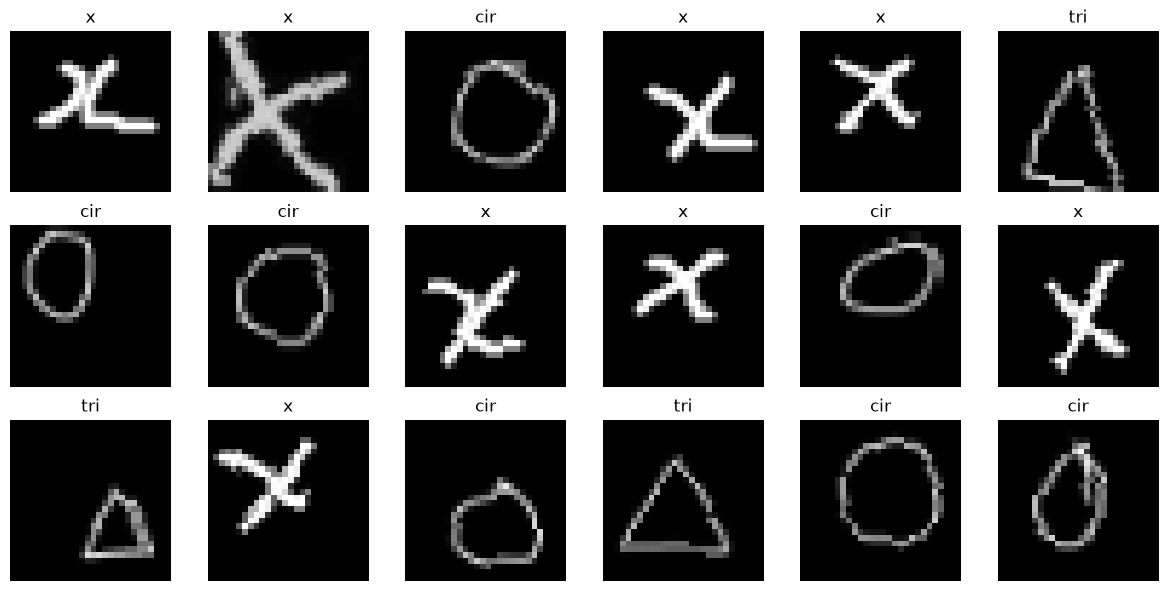

In [13]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)  # squeeze(0): 0번 자리에 있는 채널이 1이면 없애주기 >> (28*28)을 grayscale로 변환
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# **5. CNN 모델**


### Feature Map의 증가
```
1 > 28 > 28 > MaxPool
28 > 56 > 56 > MaxPool
```
- 입력 이미지는 흑백 이미지이므로 처음에는 채널이 1개
- 첫 번째 합성곱층에서는 28개의 커널이 서로 다른 특징을 학습 
  - (예: 가로선, 세로선, 대각선, 곡선, 모서리, 원의 경계, 삼각형의 꼭짓점, X의 교차점과 같은 다양한 특징을 각각 학습하게 됨)
  - 즉 입력 이미지 한 장을 하나의 특징으로 보는 것이 아니라 28개의 서로 다른 특징 맵으로 표현하게 됨
- 뒤로 갈수록 채널 수를 늘리는 이유:
  - 뒤쪽 레이어는 앞에서 학습한 특징들을 다시 조합하여 더 복잡한 특징을 찾음

### Dropout
- 학습할 때 일부 뉴런을 무작위로 비활성화 하여 과적합을 방지하는 기법
- 예) 뉴런이 100개라면 약 25개는 사용하지 않고, 약 75개만 이용하여 학습함
- 매 학습마다 비활성화되는 뉴런이 랜덤하게 달라지므로 특정 뉴런 하나에만 의존하지 않고 여러 특징을 함께 학습할 수 있게 됨.

### BatchNorm2d
- 합성곱 층의 출력값을 적절한 범위로 정규화하여 학습을 더 빠르고 안정적으로 만들어주는 층
- 예)
```
채널1 출력 [5, 9, 8, 7] > 범위 5 ~ 9
채널2 출력 [120, 140, 156, 134] > 범위 120 ~ 156
채널3 출력 [-80, -90, -130, -30] > 범위 -130 ~ -30
...
채널 32 출력 [1, 3, 5, 10] > 범위 1 ~ 10
```
- 각 채널마다 값의 범위가 다르기 때문에(다른 kernel 사용) 레이어가 학습하기 어려움
- BatchNorm은 각 채널마다 평균(0 부근), 분산(1 정도)을 계산하여 범위를 일정하게 만듦
- 학습이 빨라짐 (Loss가 더 빨리 감소)
- 값이 너무 커지거나 작아지는 현상 줄어듦

### AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마이든 상관 없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어
- CNN에서 분류 모델의 마지막 부분에 매우 자주 사용
- 예) nn.AdaptiveAvgPool2d((1, 1))라면 입력 64x64일 때, 32x32 모두 출력 1x1
  ```
  5 7 6
  8 9 2
  1 3 4
  sum(5, 7, 6, 8, 9, 2, 1, 3, 4) / 9 = 5
  ```
- CNN의 마지막에는 보통 128*7*7 같은 Feautre Map이 있음. 이 것을 Fully Connected Layer에 넣으려면 1차원으로 바꿔야 함
- Flatten 시켜서 계산하는 것과 동일
  - linear(6272, 1000)  >> 6272개의 데이터를 1000개의 클래스로 내보내겠다
  - linear(6272, 1000) >> 가중치 6272*1000 = 6272000 개
- AdaptiveAvgPool2d 계산 후 파라미터가 줄었기 때문에 linear(128, 1000) = 128000 개

In [20]:
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()  # super() 메소드: 부모 클래스의 생성자를 호출

        # layer 쌓기
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),  # 이미지 1개, 32개의 feature, kernel 3x3, padding 상하좌우 1씩, bias 없이
            nn.BatchNorm2d(32),  # 출력값 정규화
            nn.ReLU(inplace=True), # 비선형화
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),  # 이미지 32개, 32개의 feature, ...
            nn.BatchNorm2d(32),  # 출력값 정규화
            nn.ReLU(inplace=True), # 비선형화

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),  
            nn.ReLU(inplace=True),  
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),  
            nn.ReLU(inplace=True),          

            nn.MaxPool2d(kernel_size=2),
        ) 
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # 2d로 만들어 주고
            nn.Flatten(),  # 일렬로 만들어주고
            nn.Dropout(p=0.25),  # 1/4를 껐다 켰다 반복 하며 학습
            nn.Linear(64, num_classes)  # 64개를 가져와서 3개의 클래스로 반환
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

### CUDA & NVIDIA 드라이버 확인
- 최신 드라이버와 CUDA Toolkit 설치 권장
- 드라이버 버전 확인
- CUDA Version이 11.x 또는 12.x로 나오면 OK

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [22]:
model = ShapeCNN(num_classes=num_classes).to(device)